In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv("WineQT.csv")

In [3]:
df.sample(6)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
882,7.1,0.60,0.01,2.3,0.079,24.0,37.0,0.99514,3.40,0.61,10.9,6,1250
1091,7.1,0.69,0.08,2.1,0.063,42.0,52.0,0.99608,3.42,0.60,10.2,6,1529
987,8.0,0.64,0.22,2.4,0.094,5.0,33.0,0.99612,3.37,0.58,11.0,5,1391
1063,5.6,0.54,0.04,1.7,0.049,5.0,13.0,0.99420,3.72,0.58,11.4,5,1488
1017,7.8,0.64,0.00,1.9,0.072,27.0,55.0,0.99620,3.31,0.63,11.0,5,1428
269,7.7,0.51,0.28,2.1,0.087,23.0,54.0,0.99800,3.42,0.74,9.2,5,384


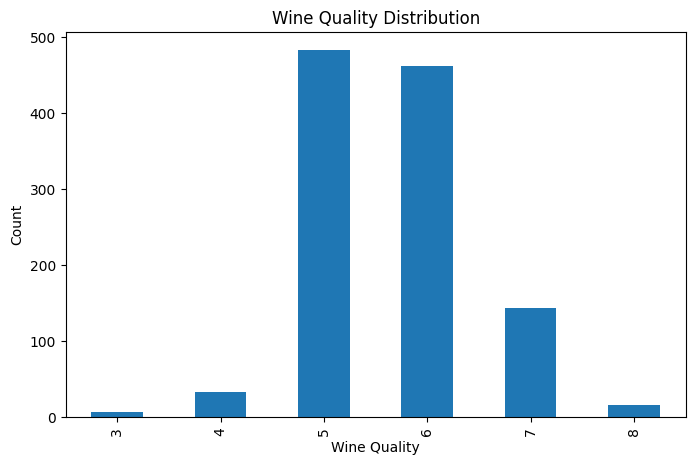

In [34]:
plt.figure(figsize=(8,5))

df['quality'].value_counts().sort_index().plot(kind='bar')

plt.xlabel("Wine Quality")
plt.ylabel("Count")
plt.title("Wine Quality Distribution")

plt.show()

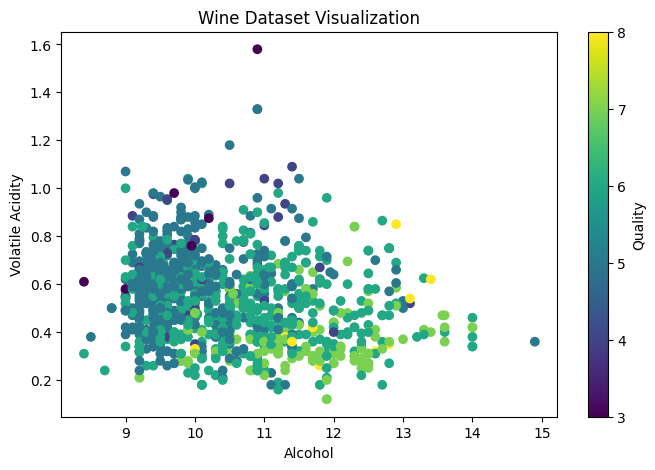

In [39]:
plt.figure(figsize=(8,5))

scatter = plt.scatter(
    df['alcohol'],
    df['volatile acidity'],
    c=df['quality']
)

plt.xlabel("Alcohol")
plt.ylabel("Volatile Acidity")
plt.title("Wine Dataset Visualization")

plt.colorbar(scatter, label="Quality")

plt.show()


In [6]:
df = df.drop(columns=["Id"])

In [8]:
x = df.drop(columns=["quality"])
y = df["quality"]

In [10]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=44)

In [11]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)
#

In [12]:
from sklearn.svm import SVC
svc = SVC()
svc.fit(x_train, y_train)
predict  = svc.predict(x_test)


In [14]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, predict)

0.6200873362445415

In [18]:
# using hyperparameter by GridSearch
from sklearn.model_selection import GridSearchCV
grid = {}
grid['C'] = [0.1, 1, 10]
grid['kernel'] = ['linear', 'rbf', 'poly']
grid['gamma'] = ['scale', 'auto']
grid['degree'] = [2, 3, 4]
grid_search = GridSearchCV(estimator=svc, param_grid=grid, cv=5,scoring = 'accuracy')
grid_result = grid_search.fit(x_train, y_train)
print(grid_result.best_score_,grid_result.best_params_)

0.6137392661982826 {'C': 1, 'degree': 2, 'gamma': 'scale', 'kernel': 'rbf'}


In [23]:
# or
from sklearn.model_selection import GridSearchCV
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto'],
    'degree': [2, 3, 4]
}
grid_search = GridSearchCV(svc, param_grid, cv=5)
grid_search.fit(x_train, y_train)
best_params = grid_search.best_params_

print(grid_result.best_score_,grid_result.best_params_)

0.6137392661982826 {'C': 1, 'degree': 2, 'gamma': 'scale', 'kernel': 'rbf'}


In [30]:
svm_classifier_optimizedparams = SVC(C=1, gamma='scale', kernel='rbf', degree=2)
svm_classifier_optimizedparams.fit(x_train, y_train)
score = svm_classifier_optimizedparams.score(x_test, y_test)
print(f'Optimized SVM Test Accuracy: {score}')

Optimized SVM Test Accuracy: 0.6200873362445415


In [ ]:
# wrt RandomSearch

In [31]:
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(
    svc,
    param_grid,
    cv=5
)

random_search.fit(x_train, y_train)

best_params_random = random_search.best_params_

print(best_params_random)
print(random_search.best_score_)

{'kernel': 'rbf', 'gamma': 'scale', 'degree': 3, 'C': 1}
0.6137392661982826


In [32]:
svm_classifier_optimizedparams = SVC(C=1, gamma='scale', kernel='rbf', degree=3)
svm_classifier_optimizedparams.fit(x_train, y_train)
score = svm_classifier_optimizedparams.score(x_test, y_test)
print(f'Optimized SVM Test Accuracy: {score}')

Optimized SVM Test Accuracy: 0.6200873362445415


In [40]:
# Predicting

In [42]:
sample = pd.DataFrame([{
    'fixed acidity': 7.1,
    'volatile acidity': 0.60,
    'citric acid': 0.01,
    'residual sugar': 2.3,
    'chlorides': 0.079,
    'free sulfur dioxide': 24.0,
    'total sulfur dioxide': 37.0,
    'density': 0.99514,
    'pH': 3.40,
    'sulphates': 0.61,
    'alcohol': 10.9
}])

sample_scaled = sc.transform(sample)

prediction = svc.predict(sample_scaled)

print(prediction[0])

6
